# Required assignment 6.2: Building a confusion matrix in Python

In this notebook, you will create confusion matrices and calculate the specificity and sensitivity of both the whole data set and each age group within the individual data sets.

You will be looking at the effectiveness of mammogram breast cancer screening for women aged 60–83. For more information on breast cancer screening, see [Breast cancer screening](https://www.cancerresearchuk.org/about-cancer/breast-cancer/getting-diagnosed/screening/breast-screening).

First, import the necessary libraries.

In [1]:
#Import the necessary libraries
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import pathlib as pl
import os
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

The data set you will be working with comes from the Breast Cancer Surveillance Consortium, an American organisation that does research into breast cancer.

### Load the data set

In [2]:
df = pd.read_csv('data/m6-dataset.csv')

In [3]:
df.shape

(40000, 13)

In [4]:
df.columns

Index(['age_c', 'assess_c', 'cancer_c', 'compfilm_c', 'density_c', 'famhx_c',
       'hrt_c', 'prvmam_c', 'biophx_c', 'mammtype', 'CaTypeO', 'bmi_c',
       'ptid'],
      dtype='str')

The data set contains 40,000 rows and 13 features. The features 'assess_c' and 'cancer_c' are of primary interest for constructing the confusion matrix.

## Section 1: Confusion matrix

### Prompt 1: Write code to create a confusion matrix for the data set.

For this data set, you will compare the radiologist's assessment to the true cancer state of the patient.

Values of  1, 2 or 3 in the assess_c column are counted as being predictions of no cancer, while values of 0, 4 or 5 are counted as being predictions of cancer.

Use the 'cancer_c' column as the true indicator of whether the patient has cancer, with 0 indicating no cancer and 1 indicating cancer.

Use these values to calculate the number of true positives, false negatives, true negatives and false positives, and plot a confusion matrix.

Hint: You can use Seaborn heatmaps to plot your confusion matrix. If you first convert your confusion matrix into a data frame with correctly labelled columns and indexes, you can get the correct labels on your heatmap.

In [9]:
#GRADED CELL
def get_confusion_matrix(df):
    """creates a confusion matrix for the breast cancer screening data
    :param df: a dataframe of the data
    :returns: np.array confusion matrix"""

    # YOUR CODE HERE
    # Create predicted labels based on assess_c
    # Values 1, 2, 3 = negative (no cancer predicted) = 0
    # Values 0, 4, 5 = positive (cancer predicted) = 1
    predicted = np.where(df['assess_c'].isin([0, 4, 5]), 1, 0)

    # True labels from cancer_c column
    # 0 = no cancer, 1 = cancer
    actual = df['cancer_c'].values

    # Calculate confusion matrix components
    TN = np.sum((predicted == 0) & (actual == 0))  # True Negative
    FP = np.sum((predicted == 1) & (actual == 0))  # False Positive
    FN = np.sum((predicted == 0) & (actual == 1))  # False Negative
    TP = np.sum((predicted == 1) & (actual == 1))  # True Positive

    # Create confusion matrix in standard format
    # [[TN, FP],
    #  [FN, TP]]
    confusion_matrix = np.array([[TN, FP],
                                  [FN, TP]])

    return confusion_matrix

In [8]:
df[df['assess_c'].isin([0, 4, 5])]
actual = df['cancer_c'].values
actual

array([0, 0, 0, ..., 0, 0, 0], shape=(40000,))

          Negative  Positive
Negative     36856      2885
Positive        33       226


Text(50.722222222222214, 0.5, 'Predicted Value')

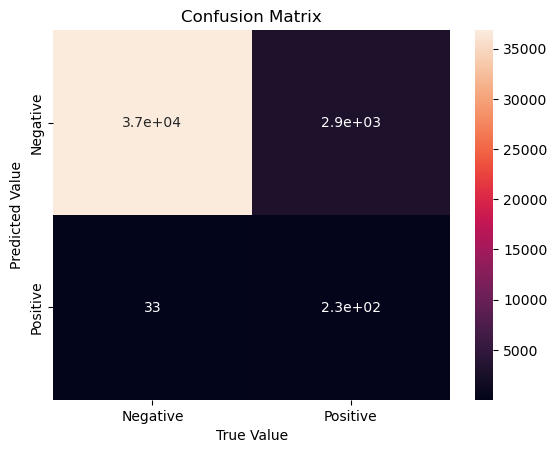

In [10]:
confusion_matrix = get_confusion_matrix(df)

plt.title('Confusion Matrix')
cf = pd.DataFrame(data = confusion_matrix, columns = ['Negative', 'Positive'], index = ['Negative', 'Positive'])
print(cf)
sn.heatmap(cf, annot=True)

plt.xlabel('True Value')
plt.ylabel('Predicted Value')

## Section 2: Calculate the sensitivity and specificity

### Prompt 2: Write a function to calculate the sensitivity and specificity of the breast cancer screening.

Calculate the sensitivity and specificity of the breast cancer screening.

**Sensitivity** =  $
\frac{\text{TP}}{\text{TP} + \text{FN}}
$

**Specificity** =  $
\frac{\text{TN}}{\text{TN} + \text{FP}}
$


In [11]:
###GRADED CELL
def calculate_sensitivity_specificity(confusion_matrix):
    """calculates sensitivity and specficity based on the True Positives,
        False Negatives, True Negatives and False Negatives and returns sensitivity ans specificity"""
    sensitivity = confusion_matrix[1, 1] / (confusion_matrix[1, 1] + confusion_matrix[1, 0])  # TP / (TP + FN)
    specificity = confusion_matrix[0, 0] / (confusion_matrix[0, 0] + confusion_matrix[0, 1])  # TN / (TN + FP)
    return sensitivity, specificity
sens, spec = calculate_sensitivity_specificity(confusion_matrix)
print(sens, spec)

0.8725868725868726 0.9274049470320324


## Section 3: Compare the different age groups

### Prompt 3: For each age group ( 60–69, 70–79 and 80–89), plot a confusion matrix, and calculate the specificity and sensitivity.

Split the data into three data sets.
1. `age_60s`, which has data with age_c < 70.
2. `age_70s`, which has data between age_c>=70 and age_c<80.
3. `age_80s`, which has data with age_c>=80.

Hint: Use `data.loc[data['age_c']` for comparing the data with the different age ranges.

In [12]:
###GRADED CELL
age_60s = df.loc[df['age_c'] < 70]
age_70s = df.loc[(df['age_c'] >= 70) & (df['age_c'] < 80)]
age_80s = df.loc[df['age_c'] >= 80]

# YOUR CODE HERE
age_dfs = [age_60s, age_70s, age_80s]

[       age_c  assess_c  cancer_c  compfilm_c  density_c  famhx_c  hrt_c  \
 0         62         1         0           1          2        0      0   
 1         65         1         0           1          4        0      0   
 2         69         0         0           1          2        0      0   
 3         64         2         0           1          2        0      0   
 4         63         3         0           1          2        0      0   
 ...      ...       ...       ...         ...        ...      ...    ...   
 39992     67         2         0           1          3        0      0   
 39993     67         1         0           1          2        0      0   
 39994     66         1         0           1          2        1      0   
 39998     66         1         0           1          2        0      0   
 39999     61         1         0           1          3        0      0   
 
        prvmam_c  biophx_c  mammtype  CaTypeO      bmi_c   ptid  
 0             1    

60-69 0.8686131386861314 0.9229264297738751
70-79 0.8735632183908046 0.9340734028092433
80-89 0.8857142857142857 0.929646017699115


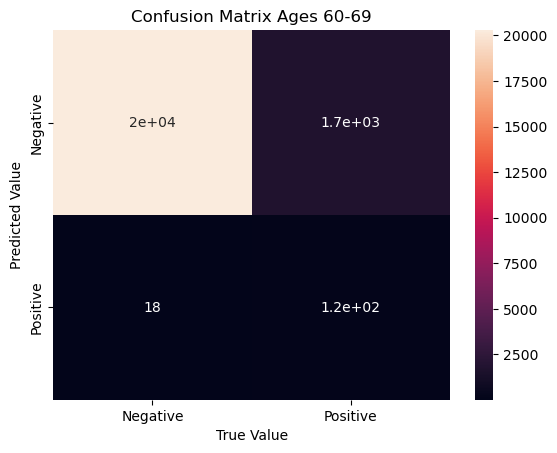

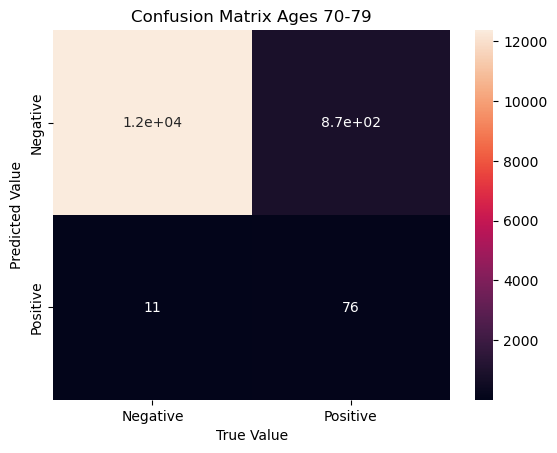

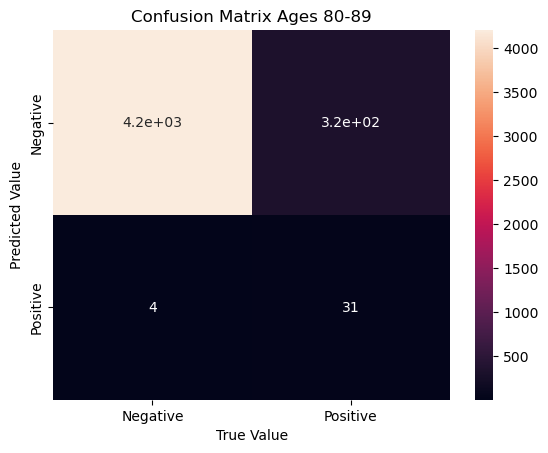

In [14]:
results = {}
ages = ['60-69', '70-79', '80-89']
for i, df in enumerate(age_dfs):
    confusion_matrix = get_confusion_matrix(df)
    results[ages[i]] = confusion_matrix

    sens, spec = calculate_sensitivity_specificity(confusion_matrix)

    fig = plt.figure()
    plt.title(f'Confusion Matrix Ages {ages[i]}')

    cf = pd.DataFrame(data = confusion_matrix, columns = ['Negative', 'Positive'], index = ['Negative', 'Positive'])
#     print(cf)
    sn.heatmap(cf, annot=True)

    plt.xlabel('True Value')
    plt.ylabel('Predicted Value')

    print(ages[i], sens, spec)

## Section 4: Compute a confusion matrix using sklearn

Instead of writing a custom `get_confusion_matrix()` function, you can use the `confusion_matrix` method from `sklearn.metrics` to compute the confusion matrix directly.

### Prompt 4: Use `confusion_matrix()` from `sklearn` to compute the confusion matrix.

In [15]:
df1 = pd.read_csv('data/m6-dataset.csv')

          Negative  Positive
Negative     36856      2885
Positive        33       226


Text(50.722222222222214, 0.5, 'Predicted Value')

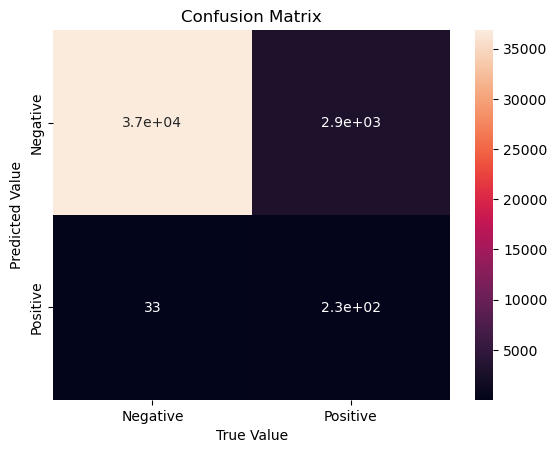

In [16]:
###GRADED CELL
from sklearn.metrics import confusion_matrix
#Create predicted labels based on assess_c
df1.loc[:, 'predicted'] = np.where(df1['assess_c'].isin([0, 4, 5]), 1, 0)

#True labels
true = df1['cancer_c']

#Predicted labels
pred = df1['predicted']
cm = confusion_matrix(true, pred)
# YOUR CODE HERE#
plt.title('Confusion Matrix')
cf = pd.DataFrame(data = cm, columns = ['Negative', 'Positive'], index = ['Negative', 'Positive'])
print(cf)
sn.heatmap(cf, annot=True)

plt.xlabel('True Value')
plt.ylabel('Predicted Value')